## Problem Statement 🧩

This project investigates **when and under what conditions** social media usage becomes harmful, using a dataset of 1,200 teenagers.


## Understanding the Dataset

This notebook aims to explore and understand the dataset I am working with. At this stage, I will not manipulate the data or make any inferences. The objective is only to describe the dataset and analyze how the variables are distributed.

This dataset was provided by Kaggle.

In [9]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install scipy


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy import stats

In [11]:
filepath = '/content/Teen_Mental_Health_Dataset.csv'
teen_health = pd.read_csv(filepath)

Let's describe the series:

In [12]:
teen_health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [13]:
teen_health.shape


(1200, 13)

In [14]:
teen_health.sample(10)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
763,18,male,3.7,Instagram,7.0,1.4,2.05,0.4,medium,10,9,5,0
629,19,male,4.7,Both,8.2,1.2,2.83,1.2,high,5,9,9,0
776,14,female,6.9,TikTok,8.0,1.6,2.64,0.1,medium,3,3,3,0
749,19,female,6.0,Both,6.3,2.8,3.98,2.0,medium,2,6,2,0
366,18,female,6.4,Instagram,7.7,0.5,3.05,1.2,low,3,1,2,0
855,18,female,1.8,Both,7.8,2.0,2.67,0.8,low,4,6,3,0
903,17,male,5.1,TikTok,5.1,2.9,3.99,0.6,medium,4,2,9,0
909,19,female,7.4,Both,8.3,1.4,3.64,0.4,low,6,9,6,0
736,16,male,6.3,Instagram,6.5,1.0,2.52,0.4,low,1,10,6,0
852,14,male,1.5,Both,6.8,0.8,3.14,0.0,medium,4,5,8,0


In [15]:
teen_health.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


## THE DATASET

Based on the results above we can say that the dataset has 1.200 teenagers, ages between 13-19, who use social media.It includes informations about their daily habtis related to the use of social media and how these behavior may relate to ther mental health. The study focuses on factors such as daily social media usage, screen time, physical activity, sleep patterns, and other lifestyle indicators to assess whether social media use may affect mental health.

## Columns Description

- age: the age of the student
- gender: the gender of the student
- daily_social_media_hours: the number of hours the student spends on social media each day
- platform_usage: the social media platform most used by the student
- sleep_hours: the number of hours the student sleeps daily
- screen_time_before_sleep: the amount of phone usage before sleeping
- academic_performance: the student’s academic performance
- physical_activity: the amount of exercise the student does each day
- social_interaction_level: the level of real-life social interaction of the student
- stress_level: the student’s stress level
- addiction_level: the level of social media addiction
- depression_label: the level or presence of depression symptoms

## Searching for empty values

In [16]:
teen_health.isnull().sum()


,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,0
sleep_hours,0
screen_time_before_sleep,0
academic_performance,0
physical_activity,0
social_interaction_level,0
stress_level,0


In [17]:
teen_health.duplicated().sum()

np.int64(0)

It seems that the dataset doesn't contains empty values


## Specific Analyses



In [18]:
display(teen_health['gender'].value_counts())

,count
gender,
male,615
female,585


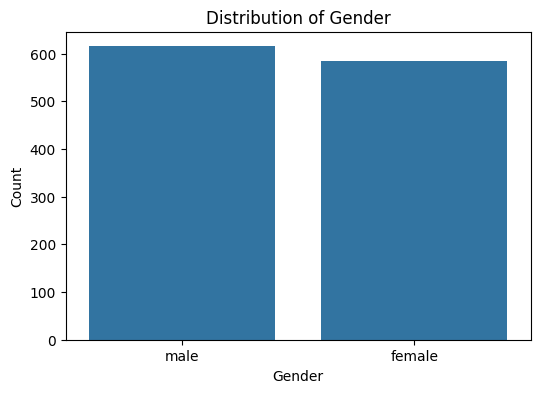

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(x='gender', data=teen_health)

plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

In [20]:
display(teen_health['platform_usage'].value_counts())

,count
platform_usage,
Instagram,411
TikTok,398
Both,391


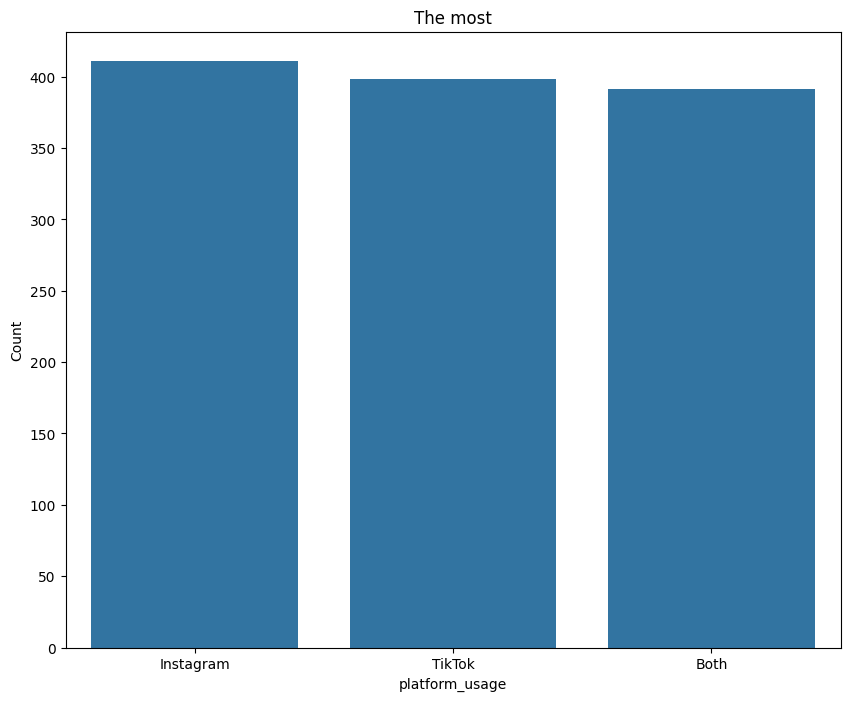

In [21]:
plt.figure(figsize=(10,8))

sns.countplot(x='platform_usage', data=teen_health)

plt.title('The most')
plt.ylabel('Count')
plt.show()

In [22]:
display(teen_health['social_interaction_level'].value_counts())

,count
social_interaction_level,
medium,416
low,415
high,369


## Making the function from scratch



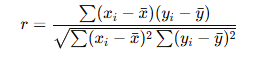

In [23]:
def manual_correlation_test(x, y):

    mean_x = x.mean()
    mean_y = y.mean()


    x_diff = x - mean_x
    y_diff = y - mean_y

    # covariance
    numerator = (x_diff * y_diff).sum()


    x_diff_sum = (x_diff ** 2).sum()
    y_diff_sum = (y_diff ** 2).sum()

    denominator = np.sqrt(x_diff_sum * y_diff_sum)

    # correlation
    r = numerator / denominator

    # sample size
    n = len(x)

    # t-stat
    t = (r * np.sqrt(n - 2)) / (np.sqrt(1 - r ** 2))

    # p-value
    p_value = 2 * (1 - stats.t.cdf(abs(t), df=n-2))

    return r, t, p_value

## Hypothesis testing

1.  H₀ (null hypothesis): There is no relationship between screen_time_before_sleep and sleep_hours.
2.    H1 (alternative hypothesis): The more screen time spent before bed, the less sleep is needed.


In [24]:
before_sleep = teen_health['screen_time_before_sleep']
sl_hours = teen_health['sleep_hours']

mean_before = before_sleep.mean()
mean_slhours = sl_hours.mean()

bdiff = before_sleep - mean_before
sdiff = sl_hours - mean_slhours

product = bdiff * sdiff

sum = product.sum()
b_diff_sum = (bdiff ** 2).sum()
sl_sum = (sdiff ** 2).sum()


deno = np.sqrt(sl_sum * b_diff_sum)
r = sum / deno
n = len(before_sleep)
t = (r * np.sqrt(n - 2)) / (np.sqrt(1 - r ** 2))
p_value = 2 * (1 - stats.t.cdf(abs(t), df=n-2))

print(f"Correlation coefficient (r): {r:.3f}")
print(f"t-statistic: {t:.3f}")
print(f"P-value: {p_value:.4f}")


Correlation coefficient (r): 0.010
t-statistic: 0.354
P-value: 0.7232


## Results

The correlation was computed manually using covariance and standard deviation to better understand the underlying statistical process, and then validated using scipy. And based on what we found it's not possible to reject the null hypothesis, indicating that there is no statistical evidence of a relationship between screen time before sleep and sleep hours.

## Hypotheses Testing

H₀: β₁ = 0 (social media usage does not predict anxiety)

H₁: β₁ > 0 (higher usage predicts higher anxiety)

##Pearson correlation test

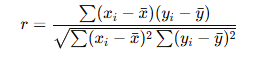

## Daily Social Media Usage vs Anxiety Level
### Hypotheses
H₀: There is no correlation between daily social media usage and anxiety level.

H₁: There is a correlation between daily social media usage and anxiety level.

In [25]:
daily_usage = teen_health['daily_social_media_hours']
anxiety_lvl = teen_health['anxiety_level']

r, t, p = manual_correlation_test(daily_usage, anxiety_lvl)

print(f"Correlation coefficient (r): {r:.3f}")
print(f"t-statistic: {t:.3f}")
print(f"P-value: {p:.4f}")




Correlation coefficient (r): 0.028
t-statistic: 0.964
P-value: 0.3353


The correlation (r = 0.028) is very weak (almost zero)

The p-value (0.3353) is greater than 0.05.

Fail to reject H₀

There is no statistically significant relationship between daily social media usage and anxiety levels.

## Daily Social Media Usage vs Academic Performance

### Hypotheses
H₀: There is no correlation between daily social media usage and academic performance.

H₁: There is a correlation between daily social media usage and academic performance.

In [26]:
daily_usage = teen_health['daily_social_media_hours']
academic_lvl = teen_health['academic_performance']

r, t, p = manual_correlation_test(daily_usage, academic_lvl)

print(f"Correlation coefficient (r): {r:.3f}")
print(f"t-statistic: {t:.3f}")
print(f"P-value: {p:.4f}")



Correlation coefficient (r): 0.013
t-statistic: 0.456
P-value: 0.6483


The correlation (r = 0.013) is negligible.

The p-value (0.6483) is much greater than 0.05.
Fail to reject H₀

There is no statistically significant relationship between social media usage and academic performance.

## Academic Performance vs Anxiety Level

### Hypotheses
H₀: There is no correlation between academic performance and anxiety level.

H₁: There is a correlation between academic performance and anxiety level.

In [27]:
academic_lvl = teen_health['academic_performance']

r, t, p = manual_correlation_test(academic_lvl, anxiety_lvl)

print(f"Correlation coefficient (r): {r:.3f}")
print(f"t-statistic: {t:.3f}")
print(f"P-value: {p:.4f}")



Correlation coefficient (r): -0.064
t-statistic: -2.233
P-value: 0.0257


There is evidence that anxiety is negatively associated with academic performance. However, no significant relationship was found between daily social media usage and anxiety, meaning it is not possible to conclude that social media usage indirectly affects academic performance through anxiety.

## Multivariate Analysis: General Correlation Matrix

To understand how all numerical variables interact with each other simultaneously, we calculate the Pearson correlation matrix and visualize it using a Heatmap. This allows us to quickly identify pairs of variables that have stronger positive or negative linear relationships, guiding deeper analyses.

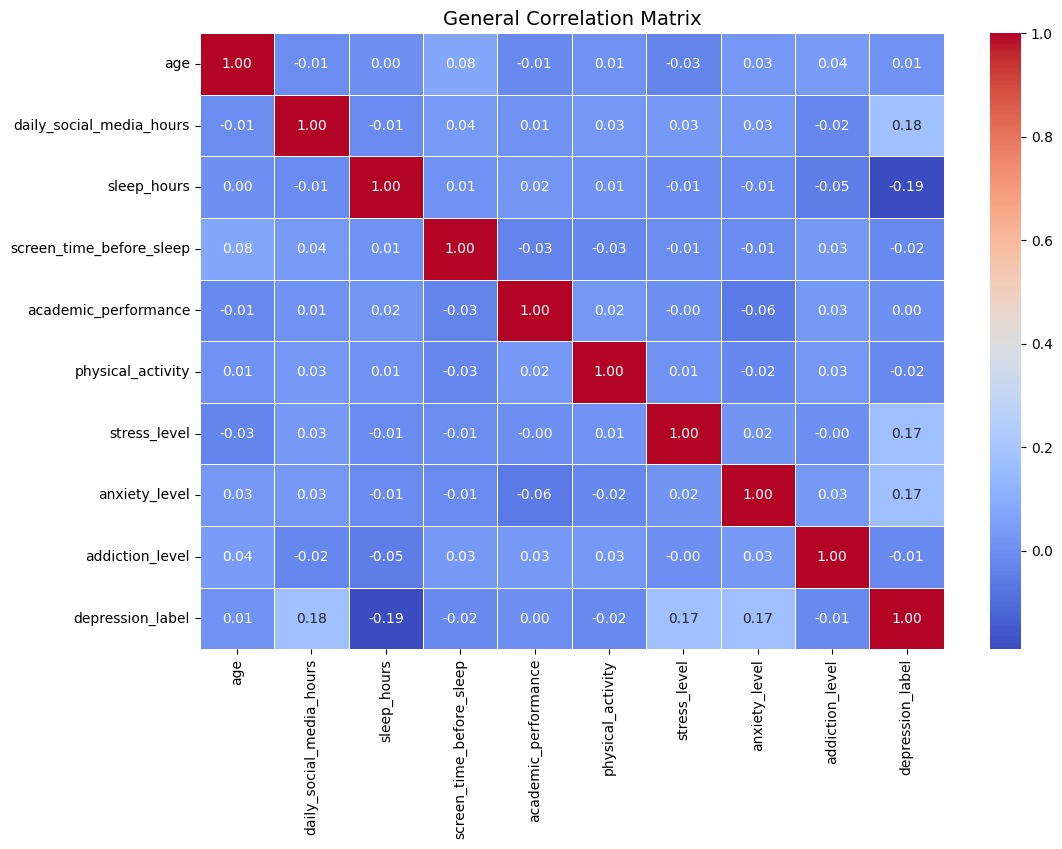

In [28]:
plt.figure(figsize=(12, 8))

# Select only numeric columns for correlation
numeric_cols = teen_health.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_cols.corr()

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('General Correlation Matrix', fontsize=14)
plt.show()

##  General Correlation Matrix Results

The correlation matrix confirms the initial hypothesis: there are no strong linear relationships among the majority of the behavioral and academic variables. Most correlation coefficients are close to zero.

**Key Findings:**
* **Negligible Linear Correlations:** Variables such as `daily_social_media_hours`, `academic_performance`, `stress_level`, and `anxiety_level` show virtually no linear correlation with each other (coefficients ranging from -0.06 to 0.08).
* **Weak Associations with Depression:** The `depression_label` exhibits the highest relative correlations in the dataset, although they remain weak:
    * Negative correlation with `sleep_hours` (-0.19), suggesting a slight tendency for lower sleep to be associated with depression.
    * Positive correlation with `daily_social_media_hours` (0.18), `stress_level` (0.17), and `anxiety_level` (0.17).

## Stress Distribution by Behavioral and Demographic Factors

To analyze the variance and distribution of an output variable across different subgroups, we use grouped Boxplots. The chart below illustrates the distribution of `stress_level` sliced by real-life `social_interaction_level` and subdivided by `gender`. This helps to verify if the impact of social isolation or high interaction differs significantly between genders.

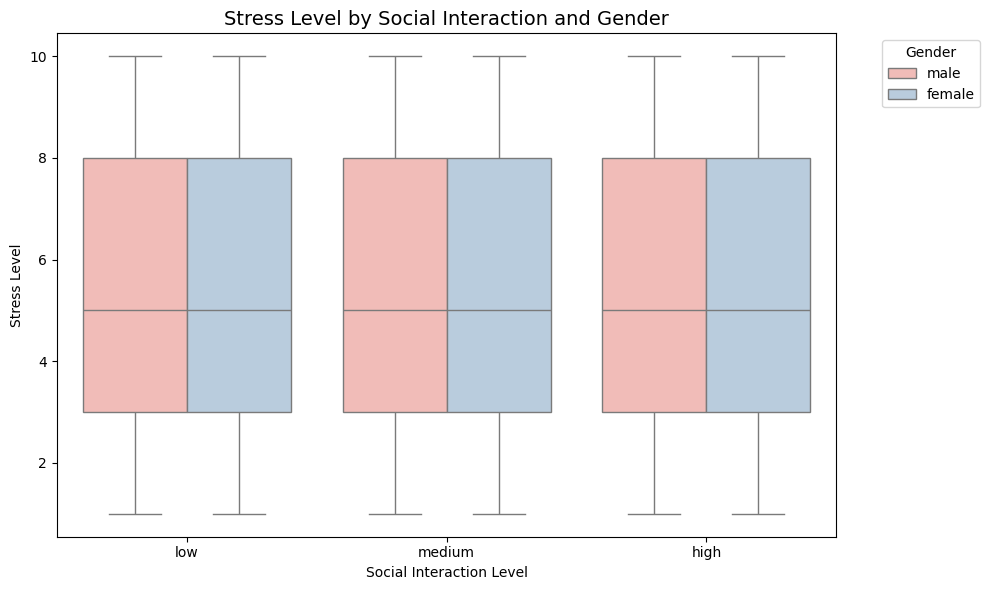

In [31]:
plt.figure(figsize=(10, 6))

# Grouped Boxplot
sns.boxplot(
    data=teen_health,
    x='social_interaction_level',
    y='stress_level',
    hue='gender',
    palette='Pastel1',
    order=['low', 'medium', 'high'] # Logically ordering the X-axis
)

plt.title('Stress Level by Social Interaction and Gender', fontsize=14)
plt.xlabel('Social Interaction Level')
plt.ylabel('Stress Level')
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 📊 Stress Level by Social Interaction and Gender Results

The grouped boxplot analysis reveals a completely uniform distribution of stress levels across all social interaction categories and genders.

**Key Findings:**
* **Uniform Distribution:** For both males and females, across low, medium, and high social interaction levels, the median stress level remains exactly at 5.
* **Consistent Variance:** The interquartile range (IQR) spans from 3 to 8, with minimum and maximum values at 1 and 10, respectively, for every single subgroup.
* **Conclusion:** Neither gender nor the reported level of real-life social interaction appears to influence the overall distribution of stress levels in this dataset. The identical distributions suggest that stress variance must be explained by other non-linear factors or combinations of variables not captured in this isolated view.

## 🔍 Deep Analysis

The initial analysis showed no significant linear correlations between social media usage and key outcomes such as anxiety and academic performance.

However, this does not necessarily imply the absence of a relationship.

Instead, it suggests that:

> The impact of social media may be **non-linear**  
> The effect may depend on **contextual and behavioral factors**


> **Under what conditions does social media usage become harmful?**


The goal is to understand whether social media is inherently harmful, or if its effects emerge only when combined with unhealthy habits such as poor sleep, high addiction, or low physical activity.


## Supervised Machine Learning: Predicting Academic Performance

Shifting the focus to `academic_performance`, we apply the Random Forest Regressor to understand which variables have the greatest non-linear impact on a student's grades. This approach will help identify if factors like sleep, physical activity, or specific social media habits are the primary drivers of academic success or failure, regardless of the lack of simple linear correlation.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import pandas as pd

# 1. Preprocessing: Convert categorical columns into numerical dummy variables
df_ml = pd.get_dummies(teen_health, drop_first=True)

# 2. Define Features (X) and Target Variable (y)
# Predicting 'academic_performance' instead of 'stress_level'
X = df_ml.drop(columns=['academic_performance'])
y = df_ml['academic_performance']

# 3. Train/Test Split (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Random Forest Model
rf_model_academic = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_academic.fit(X_train, y_train)

# 5. Model Evaluation
y_pred = rf_model_academic.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"Model R² Score for Academic Performance: {r2:.4f}")

Model R² Score for Academic Performance: -0.0727


### Feature Importance Analysis (Academic Performance)

The bar chart below ranks the features based on their contribution to the Random Forest model's predictions. By observing the top features, we can determine which lifestyle and behavioral metrics are most heavily weighted when determining a student's academic performance in this dataset.

/tmp/ipykernel_887/1603290309.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


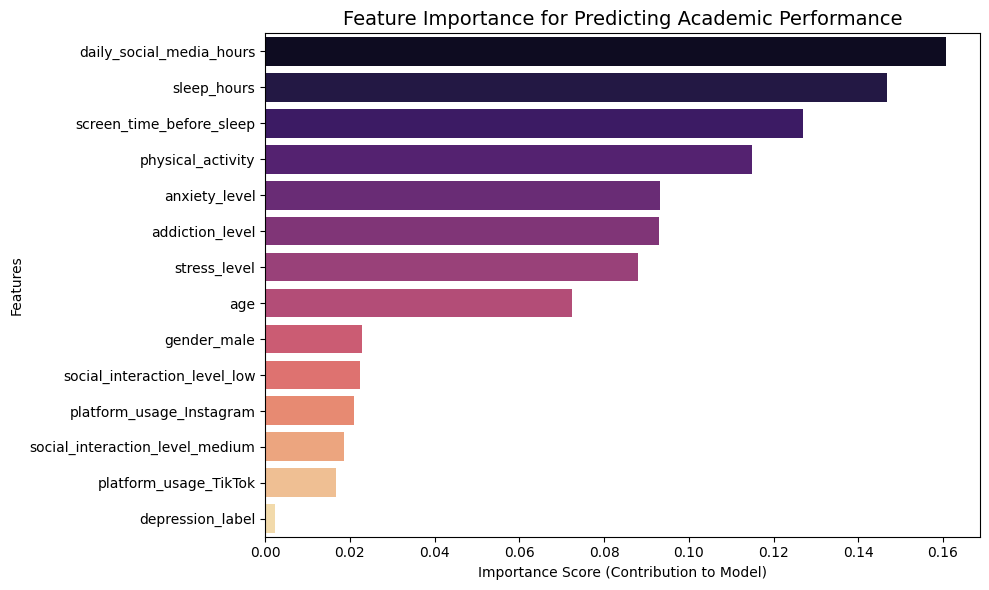

In [34]:
# Extract feature importances from the trained model
feature_importances_academic = pd.Series(
    rf_model_academic.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(
    x=feature_importances_academic,
    y=feature_importances_academic.index,
    palette='magma'
)

plt.title('Feature Importance for Predicting Academic Performance', fontsize=14)
plt.xlabel('Importance Score (Contribution to Model)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

segundo teste


Model R² Score for Addiction Level: -0.0503


/tmp/ipykernel_887/1015982409.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


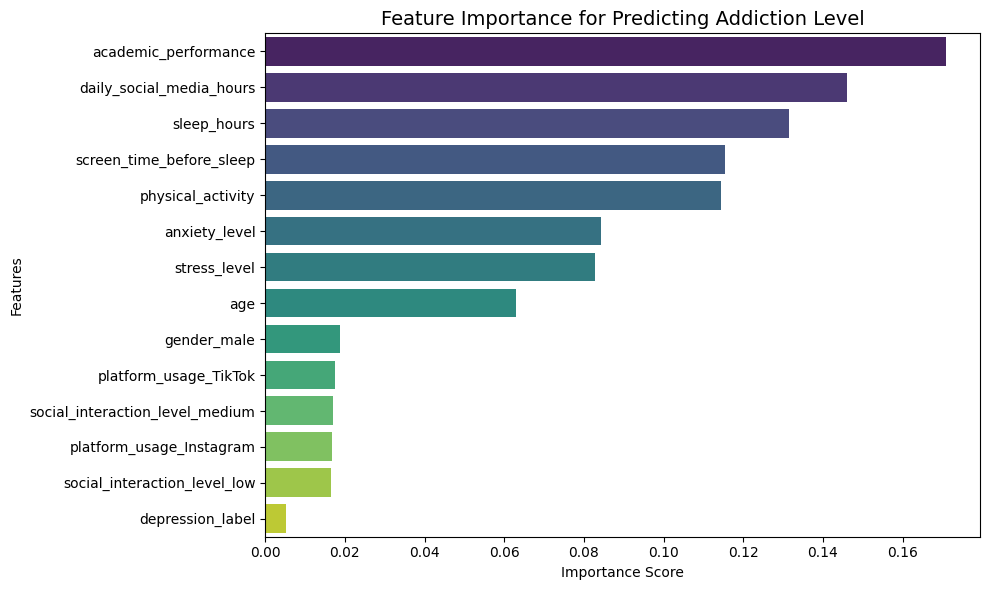

In [36]:
df_ml = pd.get_dummies(teen_health, drop_first=True)


X = df_ml.drop(columns=['addiction_level'])
y = df_ml['addiction_level']

# 3. Divisão de Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Treinamento do Modelo
rf_model_addiction = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_addiction.fit(X_train, y_train)

# 5. Avaliação
y_pred = rf_model_addiction.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"Model R² Score for Addiction Level: {r2:.4f}")

# 6. Plotagem da Importância das Variáveis
feature_importances_addiction = pd.Series(
    rf_model_addiction.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=feature_importances_addiction,
    y=feature_importances_addiction.index,
    palette='viridis'
)

plt.title('Feature Importance for Predicting Addiction Level', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## 📌 Study Conclusion

This project aimed to put into practice fundamental concepts of Data Analysis and Machine Learning, using a highly relevant topic: the impact of social media on adolescents' mental health and academic performance.

After applying descriptive statistics, hypothesis testing, and supervised Machine Learning techniques (Random Forest), the results indicated an absence of significant correlation between the variables. The predictive model presented a negative $R^2$, which suggests that the dataset features are statistically independent from the target variables (such as stress level, addiction, or academic performance). This strongly indicates that the dataset may contain randomly generated synthetic data or methodological flaws in its original collection process.

Despite this, the educational objective was fully achieved. The process of exploration, hypothesis formulation, and empirical validation lies at the core of Data Science. Discovering and mathematically proving the absence of patterns is also a valuable outcome in this field.

---

## 🚀 Next Steps

As future work and possible extensions of this project, an interesting approach would be to apply unsupervised Machine Learning algorithms, such as **K-Means**, to perform clustering and segment students into behavioral profiles.

However, my next efforts will focus on applying this analytical pipeline to a more robust, reliable, and well-structured dataset.